# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kabin-ux/fly-rank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import os
import subprocess
from pathlib import Path

# Colab setup: clone repo if not present
if Path("/content").exists() and not Path("/content/data/raw/content_refresh_anonymized.csv").exists():
    os.chdir("/content")
    subprocess.run(["git", "clone", "https://github.com/kabin-ux/fly-rank-ml-internship-starter", "."], check=True)


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

---

### Where the queue comes from

Same honest client-grouped model as Week 6 (`RandomForestClassifier`,
`GroupShuffleSplit(random_state=42)`, 22 train clients / 10 held-out test clients). The queue is
built **only from the held-out test clients** (n=10,834) -- scoring the training rows would just
replay memorization, and this is a playbook about acting on pages the model has actually proven
itself on. Ranking is entirely by `decline_probability`; everything else below (archetype, reason
code, value) is a label attached to an already-ranked row, not a second ranking signal.

**Reason codes.** Five inspectable boolean flags, not a black box: `stale` (>90 days since
update), `thin` (<2,000 words), `deep_position` (page 3+), `low_engagement`, `low_ctr` (below the
portfolio median). A row's reason code is its top two flags in that order, e.g. `stale+thin`;
`no_flags` means the model saw something these five flags do not name -- read those rows more
carefully, not less.

**Archetype -> action mapping** (checked top-down, first match wins):

| Archetype | Rule | Recommended action | Modeled on |
|---|---|---|---|
| `page1_going_stale` | page 1 / top 3 position, 181+ days since update | Priority refresh -- protect a page-one asset | FlyRank paper thesis: "protect page-one assets" |
| `old_never_refreshed` | 365+ days old, 181+ days since update | Priority refresh candidate | FlyRank Finding #4 (refresh timing) |
| `striking_distance` | positions 11-20 | Targeted relevance/internal-link push toward page 1 | FlyRank Finding #3 |
| `thin_but_visible` | <2,000 words, good/excellent impressions | Expand: add missing subtopics | FlyRank playbook step 2 |
| `deep_low_value` | position 50+, low impressions | Do not prioritize for rewrite -- monitor only | The no-go case, see Section 3 |
| `general_review` | none of the above | Standard human review, no structural pattern flagged | -- |

**The decay/refresh insight -- and an honest correction.** The FlyRank paper's headline story is
"older, staler content decays." Checked against this starter slice, restricted to the buckets with
enough rows to trust (small buckets reported, not leaned on -- see the code cell for exact n):

- **By age tier** (well-populated buckets): 91-180d -> 62.6% decline (n=11,780), 181-365d -> 51.5%
  (n=11,368), 365+d -> 42.6% (n=6,360). **Newer content declines MORE in this slice, not less** --
  the opposite direction from the paper, and it matches what Week 6 already found (the "down"
  cohort there was younger than the "up" cohort too). Two independent checks now, same direction.
- **By freshness tier**: 0-30d (recently updated) -> 51.1% (n=20,480) vs. 91-180d (untouched 3-6
  months) -> 61.1% (n=9,171) -- here staleness DOES associate with more decline, a modest,
  directional signal in the paper's expected direction. (31-90d and 181+d have only ~175 rows
  each -- too small for a headline number, reported for completeness only.)

Net: the relationship is mixed, not a clean decay curve. Two consequences: `page1_going_stale` and
`old_never_refreshed` are kept because they mirror an established playbook and a real (if partial)
freshness signal -- but in practice they barely surface at the top of this particular queue (0 of
the top 250 ranked rows carry either label; `old_never_refreshed` targets exactly the age bucket
this data shows is comparatively *stable*). Treat those two as low-volume, playbook-motivated
categories for *this* slice, not as the main driver of the ranking -- `general_review` and
`striking_distance` cover most of what the model actually flags here.

**Cost/value framing.** The queue does not invent an ROI number. It reports
`value_proxy_usd = clicks_90d x cpc` (captured click-equivalent value -- the same choice the
FlyRank paper's own Finding #9 argues for over `impressions x CPC`) alongside
`decline_probability`, and sorts rows into four **priority quadrants** for a human to weigh, rather
than one auto-computed priority score:

| Quadrant | Meaning | n (this queue) |
|---|---|---|
| `refresh_now` | High decline risk + already capturing value | 313 |
| `batch_low_touch` | High decline risk, but $0 captured value in the last 90 days | 5,104 |
| `protect_monitor` | Low decline risk, but capturing real value -- watch, don't touch | 574 |
| `deprioritize` | Low decline risk, no captured value | 4,843 |

Most "declining-looking" pages (5,104 of 5,417 high-probability rows) currently capture zero
click-equivalent value -- worth a lighter-touch batch fix, not a full rewrite. `review_batch`
(`this_week` / `this_month` / `backlog`) caps how many rows per client can land in a batch (10 per
client this week, 30 per month): an uncapped top-50-by-probability put 48 of 50 rows on just 2 of
the 10 test clients, which would have burned a week of review time on two portfolios instead of the
whole book.


In [1]:
# This cell is for CODE (numbers, a query, a check).
# Build the ranked action queue from the Week-6 honest model

def build_action_queue():
    """Rebuilds the Week-6 honest client-grouped model and turns its scores into
    a ranked action queue. Self-contained on purpose -- every section cell in this
    notebook calls this fresh rather than relying on state from an earlier cell."""
    import pandas as pd
    import numpy as np
    from pathlib import Path
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    import warnings
    warnings.filterwarnings('ignore')

    def _find_starter_csv():
        rel = Path("data/raw/content_refresh_anonymized.csv")
        cur = Path.cwd().resolve()
        for _ in range(8):
            cand = cur / rel
            if cand.exists():
                return cand
            if cur.parent == cur:
                break
            cur = cur.parent
        return None

    RAW = _find_starter_csv()
    assert RAW is not None, f"CSV not found from cwd={Path.cwd().resolve()}"
    df = pd.read_csv(RAW)
    df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

    numeric_features = [
        'search_volume', 'competition', 'cpc', 'word_count', 'char_count',
        'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
        'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
        'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update',
        'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct'
    ]
    categorical_features = [
        'competition_level', 'content_type', 'main_intent', 'age_tier',
        'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier'
    ]

    def prepare_features(frame):
        frame = frame.copy()
        for col in ['search_volume', 'competition', 'cpc']:
            frame[f'has_{col}'] = frame[col].notna().astype(int)
        num = frame[numeric_features].fillna(0)
        cat = pd.get_dummies(frame[categorical_features].astype('object'), dummy_na=True)
        flags = frame[[f'has_{c}' for c in ['search_volume', 'competition', 'cpc']]]
        return pd.concat([num, flags, cat], axis=1)

    X_all = prepare_features(df)
    y_all = df['is_declining_label'].values
    groups_all = df['client_id'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    probs_test = rf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, probs_test)

    def precision_at_k(y_true, y_scores, k):
        if len(y_scores) < k:
            k = len(y_scores)
        idx = np.argsort(-y_scores)[:k]
        return np.mean(y_true[idx])

    k_test = int(len(y_test) * (4732 / len(df)))
    baseline_csv = pd.read_csv('work/outputs/baseline_action_score.csv')
    df_test_baseline = df.iloc[test_idx].merge(baseline_csv[['content_id', 'score']], on='content_id', how='left')
    baseline_probs = df_test_baseline['score'].fillna(0).values
    rf_precision_at_k = precision_at_k(y_test, probs_test, k_test)
    baseline_precision_at_k = precision_at_k(y_test, baseline_probs, k_test)

    scored = df.iloc[test_idx].copy()
    scored['decline_probability'] = probs_test

    # ---- reason codes: five inspectable flags, not a black box ----
    med_engagement = df['engagement_rate'].median()
    med_ctr = df['ctr'].median()

    def reason_flags(row):
        flags = []
        if row['days_since_last_update'] > 90:
            flags.append('stale')
        if row['word_count_tier'] in ('<1000', '1000-2000'):
            flags.append('thin')
        if row['position_tier'] in ('deep', 'page_3_5'):
            flags.append('deep_position')
        if row['engagement_rate'] < med_engagement:
            flags.append('low_engagement')
        if row['ctr'] < med_ctr:
            flags.append('low_ctr')
        return flags

    scored['reason_flags'] = scored.apply(reason_flags, axis=1)
    scored['reason_code'] = scored['reason_flags'].apply(lambda f: '+'.join(f[:2]) if f else 'no_flags')

    # ---- archetype -> action mapping (checked top-down, first match wins) ----
    def archetype_and_action(row):
        if row['position_tier'] in ('top_3', 'page_1') and row['freshness_tier'] == '181+':
            return ('page1_going_stale', 'Priority refresh: protect a page-one asset that is aging out')
        if row['age_tier'] == '365+' and row['freshness_tier'] == '181+':
            return ('old_never_refreshed', 'Priority refresh candidate: oldest, most stale bucket')
        if row['position_tier'] == 'striking':
            return ('striking_distance', 'Targeted relevance/internal-link push toward page 1')
        if row['word_count_tier'] in ('<1000', '1000-2000') and row['impression_tier'] in ('good', 'excellent'):
            return ('thin_but_visible', 'Expand: add missing subtopics, this page already earns impressions')
        if row['position_tier'] == 'deep' and row['impression_tier'] == 'low':
            return ('deep_low_value', 'Do not prioritize for rewrite -- monitor only')
        return ('general_review', 'Standard human review queue, no specific structural pattern flagged')

    arch_action = scored.apply(archetype_and_action, axis=1, result_type='expand')
    scored['archetype'] = arch_action[0]
    scored['recommended_action'] = arch_action[1]

    # ---- cost/value framing: captured click-equivalent value (clicks x CPC), the
    # same choice the FlyRank paper's own Finding #9 argues for over impressions x CPC ----
    scored['value_proxy_usd'] = scored['clicks_90d'] * scored['cpc'].fillna(0)
    scored['value_known'] = scored['cpc'].notna()
    scored['has_captured_value'] = scored['value_known'] & (scored['value_proxy_usd'] > 0)

    med_prob = scored['decline_probability'].median()
    scored['prob_high'] = scored['decline_probability'] >= med_prob

    def quadrant(row):
        if row['prob_high'] and row['has_captured_value']:
            return 'refresh_now'
        if row['prob_high'] and not row['has_captured_value']:
            return 'batch_low_touch'
        if not row['prob_high'] and row['has_captured_value']:
            return 'protect_monitor'
        return 'deprioritize'

    scored['priority_quadrant'] = scored.apply(quadrant, axis=1)

    scored = scored.sort_values('decline_probability', ascending=False).reset_index(drop=True)
    scored.insert(0, 'rank', np.arange(1, len(scored) + 1))

    # Review batches are capped per client. An uncapped top-50-by-probability put 48
    # of 50 rows on just 2 of the 10 test clients -- this spreads review capacity
    # across the whole book instead of burning a week on two portfolios.
    def assign_batches(frame, week_total=50, week_cap_per_client=10, month_total=200, month_cap_per_client=30):
        batch = pd.Series('backlog', index=frame.index)
        client_week_count, client_month_count = {}, {}
        week_n = month_n = 0
        for idx, client in frame['client_id'].items():
            if week_n < week_total and client_week_count.get(client, 0) < week_cap_per_client:
                batch.loc[idx] = 'this_week'
                client_week_count[client] = client_week_count.get(client, 0) + 1
                week_n += 1
            elif month_n < month_total and client_month_count.get(client, 0) < month_cap_per_client:
                batch.loc[idx] = 'this_month'
                client_month_count[client] = client_month_count.get(client, 0) + 1
                month_n += 1
        return batch

    scored['review_batch'] = assign_batches(scored)

    queue_cols = [
        'rank', 'content_id', 'client_id', 'decline_probability', 'archetype',
        'recommended_action', 'reason_code', 'value_proxy_usd', 'value_known',
        'priority_quadrant', 'review_batch', 'position_tier', 'freshness_tier',
        'age_tier', 'word_count_tier',
    ]
    queue = scored[queue_cols].copy()

    metrics = {
        'model': 'RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)',
        'split': 'client-grouped 70/30 (GroupShuffleSplit, random_state=42)',
        'n_train_clients': int(len(set(df.iloc[train_idx]['client_id']))),
        'n_test_clients': int(len(set(df.iloc[test_idx]['client_id']))),
        'n_queue_rows': int(len(queue)),
        'test_auc': float(test_auc),
        'base_rate_test': float(y_test.mean()),
        'k_test': int(k_test),
        'rf_precision_at_k': float(rf_precision_at_k),
        'baseline_precision_at_k': float(baseline_precision_at_k),
        'min_content_age_days_full_dataset': int(df['content_age_days'].min()),
        'has_date_column': bool(any(
            c.lower() in ('date', 'report_date', 'snapshot_date', 'timestamp')
            or c.lower().endswith('_date') or c.lower().endswith('_at')
            for c in df.columns
        )),
        'ambiguous_probability_rows_0.45_0.55': int(((queue['decline_probability'] >= 0.45) & (queue['decline_probability'] <= 0.55)).sum()),
        'value_unknown_rows': int((~queue['value_known']).sum()),
        'archetype_counts': queue['archetype'].value_counts().to_dict(),
        'priority_quadrant_counts': queue['priority_quadrant'].value_counts().to_dict(),
        'review_batch_counts': queue['review_batch'].value_counts().to_dict(),
    }

    fresh_order = ['0-30', '31-90', '91-180', '181+']
    decay_insight = df.groupby('freshness_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(fresh_order)

    age_order = ['31-90', '91-180', '181-365', '365+']
    age_insight = df.groupby('age_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(age_order)

    return df, scored, queue, metrics, decay_insight, age_insight

import pandas as pd
pd.set_option('display.width', 120)

df, scored, queue, metrics, decay_insight, age_insight = build_action_queue()

print("=" * 80)
print("TOP OF THE RANKED QUEUE (held-out test clients only)")
print("=" * 80)
print(queue.head(10).drop(columns=['value_known']).to_string(index=False))

print("\n" + "=" * 80)
print("ARCHETYPE -> ACTION COUNTS (full queue, n=%d)" % metrics['n_queue_rows'])
print("=" * 80)
print(queue['archetype'].value_counts().to_string())

print("\n" + "=" * 80)
print("PRIORITY QUADRANTS (decline_probability x captured click-equivalent value)")
print("=" * 80)
print(queue['priority_quadrant'].value_counts().to_string())

print("\n" + "=" * 80)
print("REVIEW BATCHES (capped per client)")
print("=" * 80)
print(queue['review_batch'].value_counts().to_string())
print("\nDistinct clients in this_week batch:", queue.loc[queue['review_batch'] == 'this_week', 'client_id'].nunique(), "of", metrics['n_test_clients'])
print("Distinct clients in this_month batch:", queue.loc[queue['review_batch'] == 'this_month', 'client_id'].nunique(), "of", metrics['n_test_clients'])

print("\n" + "=" * 80)
print("THE DECAY/REFRESH INSIGHT -- checked on this slice, not assumed")
print("=" * 80)
print("\nDecline rate by content-age tier:")
print(age_insight.to_string())
print("\nDecline rate by freshness tier (days since last update):")
print(decay_insight.to_string())
print("\nWell-populated age buckets show LOWER decline as content gets older -- opposite")
print("of the FlyRank paper's headline direction, and consistent with Week 6's own")
print("reversed replication of Finding #1. Freshness moves the other way on the two")
print("well-populated buckets (0-30d vs 91-180d): staler associates with more decline")
print("there, a modest signal in the paper's expected direction.")


TOP OF THE RANKED QUEUE (held-out test clients only)
 rank           content_id         client_id  decline_probability         archetype                                                  recommended_action reason_code  value_proxy_usd priority_quadrant review_batch position_tier freshness_tier age_tier word_count_tier
    1 content_e988c1699454 client_8527a891e2             0.894263    general_review Standard human review queue, no specific structural pattern flagged  stale+thin              0.0   batch_low_touch    this_week      page_3_5         91-180  181-365       1000-2000
    2 content_bb1edbf0ba6c client_4e07408562             0.894080 striking_distance                 Targeted relevance/internal-link push toward page 1  stale+thin              0.0   batch_low_touch    this_week      striking         91-180  181-365       1000-2000
    3 content_846bb4dd8b44 client_8527a891e2             0.890429 striking_distance                 Targeted relevance/internal-link push toward page

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

---

### Who uses this, for what

A content strategist or SEO ops lead scanning `this_week`'s ~50-row batch (capped across clients)
once a week, using `reason_code` and `archetype` to decide which pages to open first. It is a
triage aid for *where to look first among thousands of pages* -- not a scoring system for
pass/fail decisions, and not a tool that touches content itself.

### Where it stops being valid

- **Single snapshot, no time axis.** This starter CSV has no date column (confirmed in the code
  cell) -- every number here is one trailing-90-day cut. There is no time-based validation (Week 6
  could only test a grouped split), so nothing here says the ranking still holds next quarter.
  Re-score before trusting it on a new period.
- **Cross-client generalization is weak, not strong.** The honest, client-grouped AUC is 0.622 --
  better than a coin flip and better than the hand-written baseline (0.679 vs. 0.619 precision@K),
  but far from a confident classifier. Treat every score as "worth a look," never as "confirmed."
- **This dataset already excludes brand-new content.** `content_age_days` never goes below 90 in
  this starter slice -- there is no content younger than ~3 months anywhere in it. The model has
  never seen a genuinely new page and should not be pointed at one.
- **Correlational, not causal.** Section 1's own decay-insight check shows the age/freshness
  relationship is mixed, not the clean "stale content decays" story the archetypes are named
  after. A recommended action means "this row looks similar to rows the model associates with
  decline," never "doing X will fix Y."
- **Anonymized starter slice, not the full warehouse.** 30,000 rows, 32 clients, one 90-day window
  -- a fraction of FlyRank's actual portfolio. Findings are directional for this slice; re-validate
  before applying the same thresholds to the full warehouse data.


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Ground the limits above in numbers, not vibes

def build_action_queue():
    """Rebuilds the Week-6 honest client-grouped model and turns its scores into
    a ranked action queue. Self-contained on purpose -- every section cell in this
    notebook calls this fresh rather than relying on state from an earlier cell."""
    import pandas as pd
    import numpy as np
    from pathlib import Path
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    import warnings
    warnings.filterwarnings('ignore')

    def _find_starter_csv():
        rel = Path("data/raw/content_refresh_anonymized.csv")
        cur = Path.cwd().resolve()
        for _ in range(8):
            cand = cur / rel
            if cand.exists():
                return cand
            if cur.parent == cur:
                break
            cur = cur.parent
        return None

    RAW = _find_starter_csv()
    assert RAW is not None, f"CSV not found from cwd={Path.cwd().resolve()}"
    df = pd.read_csv(RAW)
    df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

    numeric_features = [
        'search_volume', 'competition', 'cpc', 'word_count', 'char_count',
        'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
        'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
        'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update',
        'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct'
    ]
    categorical_features = [
        'competition_level', 'content_type', 'main_intent', 'age_tier',
        'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier'
    ]

    def prepare_features(frame):
        frame = frame.copy()
        for col in ['search_volume', 'competition', 'cpc']:
            frame[f'has_{col}'] = frame[col].notna().astype(int)
        num = frame[numeric_features].fillna(0)
        cat = pd.get_dummies(frame[categorical_features].astype('object'), dummy_na=True)
        flags = frame[[f'has_{c}' for c in ['search_volume', 'competition', 'cpc']]]
        return pd.concat([num, flags, cat], axis=1)

    X_all = prepare_features(df)
    y_all = df['is_declining_label'].values
    groups_all = df['client_id'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    probs_test = rf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, probs_test)

    def precision_at_k(y_true, y_scores, k):
        if len(y_scores) < k:
            k = len(y_scores)
        idx = np.argsort(-y_scores)[:k]
        return np.mean(y_true[idx])

    k_test = int(len(y_test) * (4732 / len(df)))
    baseline_csv = pd.read_csv('work/outputs/baseline_action_score.csv')
    df_test_baseline = df.iloc[test_idx].merge(baseline_csv[['content_id', 'score']], on='content_id', how='left')
    baseline_probs = df_test_baseline['score'].fillna(0).values
    rf_precision_at_k = precision_at_k(y_test, probs_test, k_test)
    baseline_precision_at_k = precision_at_k(y_test, baseline_probs, k_test)

    scored = df.iloc[test_idx].copy()
    scored['decline_probability'] = probs_test

    # ---- reason codes: five inspectable flags, not a black box ----
    med_engagement = df['engagement_rate'].median()
    med_ctr = df['ctr'].median()

    def reason_flags(row):
        flags = []
        if row['days_since_last_update'] > 90:
            flags.append('stale')
        if row['word_count_tier'] in ('<1000', '1000-2000'):
            flags.append('thin')
        if row['position_tier'] in ('deep', 'page_3_5'):
            flags.append('deep_position')
        if row['engagement_rate'] < med_engagement:
            flags.append('low_engagement')
        if row['ctr'] < med_ctr:
            flags.append('low_ctr')
        return flags

    scored['reason_flags'] = scored.apply(reason_flags, axis=1)
    scored['reason_code'] = scored['reason_flags'].apply(lambda f: '+'.join(f[:2]) if f else 'no_flags')

    # ---- archetype -> action mapping (checked top-down, first match wins) ----
    def archetype_and_action(row):
        if row['position_tier'] in ('top_3', 'page_1') and row['freshness_tier'] == '181+':
            return ('page1_going_stale', 'Priority refresh: protect a page-one asset that is aging out')
        if row['age_tier'] == '365+' and row['freshness_tier'] == '181+':
            return ('old_never_refreshed', 'Priority refresh candidate: oldest, most stale bucket')
        if row['position_tier'] == 'striking':
            return ('striking_distance', 'Targeted relevance/internal-link push toward page 1')
        if row['word_count_tier'] in ('<1000', '1000-2000') and row['impression_tier'] in ('good', 'excellent'):
            return ('thin_but_visible', 'Expand: add missing subtopics, this page already earns impressions')
        if row['position_tier'] == 'deep' and row['impression_tier'] == 'low':
            return ('deep_low_value', 'Do not prioritize for rewrite -- monitor only')
        return ('general_review', 'Standard human review queue, no specific structural pattern flagged')

    arch_action = scored.apply(archetype_and_action, axis=1, result_type='expand')
    scored['archetype'] = arch_action[0]
    scored['recommended_action'] = arch_action[1]

    # ---- cost/value framing: captured click-equivalent value (clicks x CPC), the
    # same choice the FlyRank paper's own Finding #9 argues for over impressions x CPC ----
    scored['value_proxy_usd'] = scored['clicks_90d'] * scored['cpc'].fillna(0)
    scored['value_known'] = scored['cpc'].notna()
    scored['has_captured_value'] = scored['value_known'] & (scored['value_proxy_usd'] > 0)

    med_prob = scored['decline_probability'].median()
    scored['prob_high'] = scored['decline_probability'] >= med_prob

    def quadrant(row):
        if row['prob_high'] and row['has_captured_value']:
            return 'refresh_now'
        if row['prob_high'] and not row['has_captured_value']:
            return 'batch_low_touch'
        if not row['prob_high'] and row['has_captured_value']:
            return 'protect_monitor'
        return 'deprioritize'

    scored['priority_quadrant'] = scored.apply(quadrant, axis=1)

    scored = scored.sort_values('decline_probability', ascending=False).reset_index(drop=True)
    scored.insert(0, 'rank', np.arange(1, len(scored) + 1))

    # Review batches are capped per client. An uncapped top-50-by-probability put 48
    # of 50 rows on just 2 of the 10 test clients -- this spreads review capacity
    # across the whole book instead of burning a week on two portfolios.
    def assign_batches(frame, week_total=50, week_cap_per_client=10, month_total=200, month_cap_per_client=30):
        batch = pd.Series('backlog', index=frame.index)
        client_week_count, client_month_count = {}, {}
        week_n = month_n = 0
        for idx, client in frame['client_id'].items():
            if week_n < week_total and client_week_count.get(client, 0) < week_cap_per_client:
                batch.loc[idx] = 'this_week'
                client_week_count[client] = client_week_count.get(client, 0) + 1
                week_n += 1
            elif month_n < month_total and client_month_count.get(client, 0) < month_cap_per_client:
                batch.loc[idx] = 'this_month'
                client_month_count[client] = client_month_count.get(client, 0) + 1
                month_n += 1
        return batch

    scored['review_batch'] = assign_batches(scored)

    queue_cols = [
        'rank', 'content_id', 'client_id', 'decline_probability', 'archetype',
        'recommended_action', 'reason_code', 'value_proxy_usd', 'value_known',
        'priority_quadrant', 'review_batch', 'position_tier', 'freshness_tier',
        'age_tier', 'word_count_tier',
    ]
    queue = scored[queue_cols].copy()

    metrics = {
        'model': 'RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)',
        'split': 'client-grouped 70/30 (GroupShuffleSplit, random_state=42)',
        'n_train_clients': int(len(set(df.iloc[train_idx]['client_id']))),
        'n_test_clients': int(len(set(df.iloc[test_idx]['client_id']))),
        'n_queue_rows': int(len(queue)),
        'test_auc': float(test_auc),
        'base_rate_test': float(y_test.mean()),
        'k_test': int(k_test),
        'rf_precision_at_k': float(rf_precision_at_k),
        'baseline_precision_at_k': float(baseline_precision_at_k),
        'min_content_age_days_full_dataset': int(df['content_age_days'].min()),
        'has_date_column': bool(any(
            c.lower() in ('date', 'report_date', 'snapshot_date', 'timestamp')
            or c.lower().endswith('_date') or c.lower().endswith('_at')
            for c in df.columns
        )),
        'ambiguous_probability_rows_0.45_0.55': int(((queue['decline_probability'] >= 0.45) & (queue['decline_probability'] <= 0.55)).sum()),
        'value_unknown_rows': int((~queue['value_known']).sum()),
        'archetype_counts': queue['archetype'].value_counts().to_dict(),
        'priority_quadrant_counts': queue['priority_quadrant'].value_counts().to_dict(),
        'review_batch_counts': queue['review_batch'].value_counts().to_dict(),
    }

    fresh_order = ['0-30', '31-90', '91-180', '181+']
    decay_insight = df.groupby('freshness_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(fresh_order)

    age_order = ['31-90', '91-180', '181-365', '365+']
    age_insight = df.groupby('age_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(age_order)

    return df, scored, queue, metrics, decay_insight, age_insight

df, scored, queue, metrics, decay_insight, age_insight = build_action_queue()

print("=" * 80)
print("WHAT THIS MODEL HAS AND HAS NOT BEEN SHOWN TO DO")
print("=" * 80)
print(f"Has a date/timestamp column: {metrics['has_date_column']} -- no time-based validation is possible on this slice.")
print(f"Train clients: {metrics['n_train_clients']}, test clients: {metrics['n_test_clients']} (client-grouped split)")
print(f"Held-out AUC: {metrics['test_auc']:.3f} (0.5 = coin flip)")
print(f"Held-out base rate: {metrics['base_rate_test']:.1%}")
print(f"Precision@K (K={metrics['k_test']}): Random Forest {metrics['rf_precision_at_k']:.3f} vs. baseline rule {metrics['baseline_precision_at_k']:.3f}")
print(f"Minimum content_age_days anywhere in the full 30,000-row dataset: {metrics['min_content_age_days_full_dataset']} days")
print("\nReading these together: the model beats the hand-written baseline on clients it has")
print("never seen, but an AUC of 0.622 is a modest edge, not a confident classifier -- and")
print("it has literally never seen a page younger than 90 days, so it says nothing about one.")


WHAT THIS MODEL HAS AND HAS NOT BEEN SHOWN TO DO
Has a date/timestamp column: False -- no time-based validation is possible on this slice.
Train clients: 22, test clients: 10 (client-grouped split)
Held-out AUC: 0.622 (0.5 = coin flip)
Held-out base rate: 55.9%
Precision@K (K=1708): Random Forest 0.679 vs. baseline rule 0.619
Minimum content_age_days anywhere in the full 30,000-row dataset: 90 days

Reading these together: the model beats the hand-written baseline on clients it has
never seen, but an AUC of 0.622 is a modest edge, not a confident classifier -- and
it has literally never seen a page younger than 90 days, so it says nothing about one.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

---

### What a person must check before acting on any row

- **Read the actual page.** `reason_code` and `archetype` summarize ~30 numeric/categorical
  columns -- they cannot see editorial quality, brand voice, factual accuracy, or whether the page
  still matches the business's current offering.
- **Check for cannibalization manually.** The FlyRank paper's own portfolio has 73.2M impressions
  tied up in overlapping-query pages; nothing in this starter slice's columns detects
  duplicate/competing pages on the same client's site. A human has to check that separately before
  recommending a rewrite.
- **Confirm the client is still active and in scope.** Pseudonymized `client_id`s here carry no
  business context (compliance status, contract terms, pending migration) that would change the
  answer.

### What should NEVER be automated

1. **No auto-publish, ever.** Nothing in this pipeline edits, republishes, de-indexes, or removes
   content. Every row is a suggestion for a human's worklist, full stop.
2. **No action on ambiguous rows without a second look.** ~13% of rows sit in the 0.45-0.55
   probability band (exact count in the code cell) -- close enough to a coin flip that flagging
   them with the same confidence as a 0.89-probability row would misrepresent what the model
   actually knows. Route these to manual review, not to the top of anyone's queue.
3. **No action on content younger than the data supports.** Nothing under ~90 days old is in scope
   for this model (Section 2) -- don't extend its recommendations to brand-new pages.
4. **No unreviewed action on `refresh_now` rows.** These are high decline risk AND already
   capturing measurable value -- a mistake here has real cost. They need a second sign-off (e.g.,
   the account owner), not just the assigned reviewer.
5. **No treating the product's own optimization flags as ground truth**, and by the same logic, no
   treating this playbook's own output as ground truth for a future model (see the leakage note in
   Week 6). This queue is a baseline to argue with, not a new source of truth to blindly retrain
   on.
6. **No cross-portfolio copy-paste.** A `page1_going_stale` label here reflects this dataset's
   rules; the same label on the full warehouse data needs its own validation before the
   recommended action is trusted.

### No-go list -- do not queue at all

- Content younger than ~90 days (outside the model's seen distribution).
- Treating a `value_known = False` row (no keyword/CPC data) as high-value -- it defaults to the
  conservative side of the priority quadrant instead of being assumed valuable just because it
  wasn't measured.
- Any row where `reason_code == 'no_flags'` AND `archetype == 'general_review'` AND the probability
  is in the ambiguous band, all at once -- three separate signals that the model isn't telling a
  clear story, which is a manual-look case by definition, never an automation candidate.


In [3]:
# This cell is for CODE (numbers, a query, a check).
# Quantify the no-go cases instead of asserting them

def build_action_queue():
    """Rebuilds the Week-6 honest client-grouped model and turns its scores into
    a ranked action queue. Self-contained on purpose -- every section cell in this
    notebook calls this fresh rather than relying on state from an earlier cell."""
    import pandas as pd
    import numpy as np
    from pathlib import Path
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    import warnings
    warnings.filterwarnings('ignore')

    def _find_starter_csv():
        rel = Path("data/raw/content_refresh_anonymized.csv")
        cur = Path.cwd().resolve()
        for _ in range(8):
            cand = cur / rel
            if cand.exists():
                return cand
            if cur.parent == cur:
                break
            cur = cur.parent
        return None

    RAW = _find_starter_csv()
    assert RAW is not None, f"CSV not found from cwd={Path.cwd().resolve()}"
    df = pd.read_csv(RAW)
    df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

    numeric_features = [
        'search_volume', 'competition', 'cpc', 'word_count', 'char_count',
        'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
        'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
        'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update',
        'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct'
    ]
    categorical_features = [
        'competition_level', 'content_type', 'main_intent', 'age_tier',
        'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier'
    ]

    def prepare_features(frame):
        frame = frame.copy()
        for col in ['search_volume', 'competition', 'cpc']:
            frame[f'has_{col}'] = frame[col].notna().astype(int)
        num = frame[numeric_features].fillna(0)
        cat = pd.get_dummies(frame[categorical_features].astype('object'), dummy_na=True)
        flags = frame[[f'has_{c}' for c in ['search_volume', 'competition', 'cpc']]]
        return pd.concat([num, flags, cat], axis=1)

    X_all = prepare_features(df)
    y_all = df['is_declining_label'].values
    groups_all = df['client_id'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    probs_test = rf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, probs_test)

    def precision_at_k(y_true, y_scores, k):
        if len(y_scores) < k:
            k = len(y_scores)
        idx = np.argsort(-y_scores)[:k]
        return np.mean(y_true[idx])

    k_test = int(len(y_test) * (4732 / len(df)))
    baseline_csv = pd.read_csv('work/outputs/baseline_action_score.csv')
    df_test_baseline = df.iloc[test_idx].merge(baseline_csv[['content_id', 'score']], on='content_id', how='left')
    baseline_probs = df_test_baseline['score'].fillna(0).values
    rf_precision_at_k = precision_at_k(y_test, probs_test, k_test)
    baseline_precision_at_k = precision_at_k(y_test, baseline_probs, k_test)

    scored = df.iloc[test_idx].copy()
    scored['decline_probability'] = probs_test

    # ---- reason codes: five inspectable flags, not a black box ----
    med_engagement = df['engagement_rate'].median()
    med_ctr = df['ctr'].median()

    def reason_flags(row):
        flags = []
        if row['days_since_last_update'] > 90:
            flags.append('stale')
        if row['word_count_tier'] in ('<1000', '1000-2000'):
            flags.append('thin')
        if row['position_tier'] in ('deep', 'page_3_5'):
            flags.append('deep_position')
        if row['engagement_rate'] < med_engagement:
            flags.append('low_engagement')
        if row['ctr'] < med_ctr:
            flags.append('low_ctr')
        return flags

    scored['reason_flags'] = scored.apply(reason_flags, axis=1)
    scored['reason_code'] = scored['reason_flags'].apply(lambda f: '+'.join(f[:2]) if f else 'no_flags')

    # ---- archetype -> action mapping (checked top-down, first match wins) ----
    def archetype_and_action(row):
        if row['position_tier'] in ('top_3', 'page_1') and row['freshness_tier'] == '181+':
            return ('page1_going_stale', 'Priority refresh: protect a page-one asset that is aging out')
        if row['age_tier'] == '365+' and row['freshness_tier'] == '181+':
            return ('old_never_refreshed', 'Priority refresh candidate: oldest, most stale bucket')
        if row['position_tier'] == 'striking':
            return ('striking_distance', 'Targeted relevance/internal-link push toward page 1')
        if row['word_count_tier'] in ('<1000', '1000-2000') and row['impression_tier'] in ('good', 'excellent'):
            return ('thin_but_visible', 'Expand: add missing subtopics, this page already earns impressions')
        if row['position_tier'] == 'deep' and row['impression_tier'] == 'low':
            return ('deep_low_value', 'Do not prioritize for rewrite -- monitor only')
        return ('general_review', 'Standard human review queue, no specific structural pattern flagged')

    arch_action = scored.apply(archetype_and_action, axis=1, result_type='expand')
    scored['archetype'] = arch_action[0]
    scored['recommended_action'] = arch_action[1]

    # ---- cost/value framing: captured click-equivalent value (clicks x CPC), the
    # same choice the FlyRank paper's own Finding #9 argues for over impressions x CPC ----
    scored['value_proxy_usd'] = scored['clicks_90d'] * scored['cpc'].fillna(0)
    scored['value_known'] = scored['cpc'].notna()
    scored['has_captured_value'] = scored['value_known'] & (scored['value_proxy_usd'] > 0)

    med_prob = scored['decline_probability'].median()
    scored['prob_high'] = scored['decline_probability'] >= med_prob

    def quadrant(row):
        if row['prob_high'] and row['has_captured_value']:
            return 'refresh_now'
        if row['prob_high'] and not row['has_captured_value']:
            return 'batch_low_touch'
        if not row['prob_high'] and row['has_captured_value']:
            return 'protect_monitor'
        return 'deprioritize'

    scored['priority_quadrant'] = scored.apply(quadrant, axis=1)

    scored = scored.sort_values('decline_probability', ascending=False).reset_index(drop=True)
    scored.insert(0, 'rank', np.arange(1, len(scored) + 1))

    # Review batches are capped per client. An uncapped top-50-by-probability put 48
    # of 50 rows on just 2 of the 10 test clients -- this spreads review capacity
    # across the whole book instead of burning a week on two portfolios.
    def assign_batches(frame, week_total=50, week_cap_per_client=10, month_total=200, month_cap_per_client=30):
        batch = pd.Series('backlog', index=frame.index)
        client_week_count, client_month_count = {}, {}
        week_n = month_n = 0
        for idx, client in frame['client_id'].items():
            if week_n < week_total and client_week_count.get(client, 0) < week_cap_per_client:
                batch.loc[idx] = 'this_week'
                client_week_count[client] = client_week_count.get(client, 0) + 1
                week_n += 1
            elif month_n < month_total and client_month_count.get(client, 0) < month_cap_per_client:
                batch.loc[idx] = 'this_month'
                client_month_count[client] = client_month_count.get(client, 0) + 1
                month_n += 1
        return batch

    scored['review_batch'] = assign_batches(scored)

    queue_cols = [
        'rank', 'content_id', 'client_id', 'decline_probability', 'archetype',
        'recommended_action', 'reason_code', 'value_proxy_usd', 'value_known',
        'priority_quadrant', 'review_batch', 'position_tier', 'freshness_tier',
        'age_tier', 'word_count_tier',
    ]
    queue = scored[queue_cols].copy()

    metrics = {
        'model': 'RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)',
        'split': 'client-grouped 70/30 (GroupShuffleSplit, random_state=42)',
        'n_train_clients': int(len(set(df.iloc[train_idx]['client_id']))),
        'n_test_clients': int(len(set(df.iloc[test_idx]['client_id']))),
        'n_queue_rows': int(len(queue)),
        'test_auc': float(test_auc),
        'base_rate_test': float(y_test.mean()),
        'k_test': int(k_test),
        'rf_precision_at_k': float(rf_precision_at_k),
        'baseline_precision_at_k': float(baseline_precision_at_k),
        'min_content_age_days_full_dataset': int(df['content_age_days'].min()),
        'has_date_column': bool(any(
            c.lower() in ('date', 'report_date', 'snapshot_date', 'timestamp')
            or c.lower().endswith('_date') or c.lower().endswith('_at')
            for c in df.columns
        )),
        'ambiguous_probability_rows_0.45_0.55': int(((queue['decline_probability'] >= 0.45) & (queue['decline_probability'] <= 0.55)).sum()),
        'value_unknown_rows': int((~queue['value_known']).sum()),
        'archetype_counts': queue['archetype'].value_counts().to_dict(),
        'priority_quadrant_counts': queue['priority_quadrant'].value_counts().to_dict(),
        'review_batch_counts': queue['review_batch'].value_counts().to_dict(),
    }

    fresh_order = ['0-30', '31-90', '91-180', '181+']
    decay_insight = df.groupby('freshness_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(fresh_order)

    age_order = ['31-90', '91-180', '181-365', '365+']
    age_insight = df.groupby('age_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(age_order)

    return df, scored, queue, metrics, decay_insight, age_insight

df, scored, queue, metrics, decay_insight, age_insight = build_action_queue()

print("=" * 80)
print("ROWS THAT SHOULD NOT BE AUTOMATED, COUNTED")
print("=" * 80)
n_ambiguous = metrics['ambiguous_probability_rows_0.45_0.55']
print(f"Ambiguous probability (0.45-0.55), i.e. close to a coin flip: {n_ambiguous} of {metrics['n_queue_rows']} rows ({n_ambiguous/metrics['n_queue_rows']:.1%})")
print("  -> route to manual review, never queue these with the same confidence as a 0.89 row.")

n_value_unknown = metrics['value_unknown_rows']
print(f"\nNo CPC/keyword data at all (value_known=False): {n_value_unknown} rows")
print("  -> these default to the conservative side of the value quadrant rather than being")
print("     assumed valuable just because they weren't measured.")

n_refresh_now = metrics['priority_quadrant_counts'].get('refresh_now', 0)
print(f"\n'refresh_now' rows (high decline risk AND already capturing measurable value): {n_refresh_now}")
print("  -> these carry real cost if acted on wrong. Second sign-off (e.g. account owner),")
print("     not just the assigned reviewer.")

triple_flag = queue[
    (queue['reason_code'] == 'no_flags')
    & (queue['archetype'] == 'general_review')
    & (queue['decline_probability'] >= 0.45)
    & (queue['decline_probability'] <= 0.55)
]
print(f"\nRows with no_flags + general_review + ambiguous probability, all at once: {len(triple_flag)}")
print("  -> three separate signals of 'the model is not telling a clear story here' -- a")
print("     manual-look case by definition, never an automation candidate.")

print(f"\nContent below this model's observed age floor ({metrics['min_content_age_days_full_dataset']} days): by")
print("  construction, zero rows in this dataset -- but the rule still applies going forward:")
print("  never point this model at content younger than that floor.")


ROWS THAT SHOULD NOT BE AUTOMATED, COUNTED
Ambiguous probability (0.45-0.55), i.e. close to a coin flip: 1406 of 10834 rows (13.0%)
  -> route to manual review, never queue these with the same confidence as a 0.89 row.

No CPC/keyword data at all (value_known=False): 151 rows
  -> these default to the conservative side of the value quadrant rather than being
     assumed valuable just because they weren't measured.

'refresh_now' rows (high decline risk AND already capturing measurable value): 313
  -> these carry real cost if acted on wrong. Second sign-off (e.g. account owner),
     not just the assigned reviewer.

Rows with no_flags + general_review + ambiguous probability, all at once: 349
  -> three separate signals of 'the model is not telling a clear story here' -- a
     manual-look case by definition, never an automation candidate.

Content below this model's observed age floor (90 days): by
  construction, zero rows in this dataset -- but the rule still applies going forward:

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

---

### Light monitoring, on purpose -- this is not a production system

Three cheap checks, each comparing a fresh score against the receipt numbers already committed in
`work/outputs/action_playbook_metrics.json`:

1. **Base-rate drift.** Reference: 55.9% decline rate on the held-out clients. If a fresh sample's
   decline rate moves more than ~10 points from that (i.e., outside roughly 46%-66%), the
   portfolio has changed enough that the model's calibration should not be trusted until
   re-checked.
2. **Precision@K floor.** Reference: Random Forest 0.679 precision@K vs. baseline rule 0.619 on the
   same held-out clients. If a fresh precision@K check ever drops at or below the baseline rule's
   number, the model has stopped earning its keep -- fall back to the baseline rule until
   retrained.
3. **New-client / new-period trigger.** Onboarding a client the model has never scored, or moving
   to a new reporting window, is an automatic retrain-and-revalidate trigger, not an optional one
   -- Section 2 already established the model has no time-based validation and no evidence it
   generalizes to an unseen client's *specific* quirks beyond the 0.622 AUC average.

No dashboards, no automated alerts -- these are three numbers a human recomputes from the same code
as this notebook, on a cadence like monthly or whenever new client data lands, and compares to the
JSON receipt by eye.


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Light monitoring: three cheap checks against the committed receipt numbers

def build_action_queue():
    """Rebuilds the Week-6 honest client-grouped model and turns its scores into
    a ranked action queue. Self-contained on purpose -- every section cell in this
    notebook calls this fresh rather than relying on state from an earlier cell."""
    import pandas as pd
    import numpy as np
    from pathlib import Path
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    import warnings
    warnings.filterwarnings('ignore')

    def _find_starter_csv():
        rel = Path("data/raw/content_refresh_anonymized.csv")
        cur = Path.cwd().resolve()
        for _ in range(8):
            cand = cur / rel
            if cand.exists():
                return cand
            if cur.parent == cur:
                break
            cur = cur.parent
        return None

    RAW = _find_starter_csv()
    assert RAW is not None, f"CSV not found from cwd={Path.cwd().resolve()}"
    df = pd.read_csv(RAW)
    df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

    numeric_features = [
        'search_volume', 'competition', 'cpc', 'word_count', 'char_count',
        'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
        'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
        'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update',
        'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct'
    ]
    categorical_features = [
        'competition_level', 'content_type', 'main_intent', 'age_tier',
        'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier'
    ]

    def prepare_features(frame):
        frame = frame.copy()
        for col in ['search_volume', 'competition', 'cpc']:
            frame[f'has_{col}'] = frame[col].notna().astype(int)
        num = frame[numeric_features].fillna(0)
        cat = pd.get_dummies(frame[categorical_features].astype('object'), dummy_na=True)
        flags = frame[[f'has_{c}' for c in ['search_volume', 'competition', 'cpc']]]
        return pd.concat([num, flags, cat], axis=1)

    X_all = prepare_features(df)
    y_all = df['is_declining_label'].values
    groups_all = df['client_id'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    probs_test = rf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, probs_test)

    def precision_at_k(y_true, y_scores, k):
        if len(y_scores) < k:
            k = len(y_scores)
        idx = np.argsort(-y_scores)[:k]
        return np.mean(y_true[idx])

    k_test = int(len(y_test) * (4732 / len(df)))
    baseline_csv = pd.read_csv('work/outputs/baseline_action_score.csv')
    df_test_baseline = df.iloc[test_idx].merge(baseline_csv[['content_id', 'score']], on='content_id', how='left')
    baseline_probs = df_test_baseline['score'].fillna(0).values
    rf_precision_at_k = precision_at_k(y_test, probs_test, k_test)
    baseline_precision_at_k = precision_at_k(y_test, baseline_probs, k_test)

    scored = df.iloc[test_idx].copy()
    scored['decline_probability'] = probs_test

    # ---- reason codes: five inspectable flags, not a black box ----
    med_engagement = df['engagement_rate'].median()
    med_ctr = df['ctr'].median()

    def reason_flags(row):
        flags = []
        if row['days_since_last_update'] > 90:
            flags.append('stale')
        if row['word_count_tier'] in ('<1000', '1000-2000'):
            flags.append('thin')
        if row['position_tier'] in ('deep', 'page_3_5'):
            flags.append('deep_position')
        if row['engagement_rate'] < med_engagement:
            flags.append('low_engagement')
        if row['ctr'] < med_ctr:
            flags.append('low_ctr')
        return flags

    scored['reason_flags'] = scored.apply(reason_flags, axis=1)
    scored['reason_code'] = scored['reason_flags'].apply(lambda f: '+'.join(f[:2]) if f else 'no_flags')

    # ---- archetype -> action mapping (checked top-down, first match wins) ----
    def archetype_and_action(row):
        if row['position_tier'] in ('top_3', 'page_1') and row['freshness_tier'] == '181+':
            return ('page1_going_stale', 'Priority refresh: protect a page-one asset that is aging out')
        if row['age_tier'] == '365+' and row['freshness_tier'] == '181+':
            return ('old_never_refreshed', 'Priority refresh candidate: oldest, most stale bucket')
        if row['position_tier'] == 'striking':
            return ('striking_distance', 'Targeted relevance/internal-link push toward page 1')
        if row['word_count_tier'] in ('<1000', '1000-2000') and row['impression_tier'] in ('good', 'excellent'):
            return ('thin_but_visible', 'Expand: add missing subtopics, this page already earns impressions')
        if row['position_tier'] == 'deep' and row['impression_tier'] == 'low':
            return ('deep_low_value', 'Do not prioritize for rewrite -- monitor only')
        return ('general_review', 'Standard human review queue, no specific structural pattern flagged')

    arch_action = scored.apply(archetype_and_action, axis=1, result_type='expand')
    scored['archetype'] = arch_action[0]
    scored['recommended_action'] = arch_action[1]

    # ---- cost/value framing: captured click-equivalent value (clicks x CPC), the
    # same choice the FlyRank paper's own Finding #9 argues for over impressions x CPC ----
    scored['value_proxy_usd'] = scored['clicks_90d'] * scored['cpc'].fillna(0)
    scored['value_known'] = scored['cpc'].notna()
    scored['has_captured_value'] = scored['value_known'] & (scored['value_proxy_usd'] > 0)

    med_prob = scored['decline_probability'].median()
    scored['prob_high'] = scored['decline_probability'] >= med_prob

    def quadrant(row):
        if row['prob_high'] and row['has_captured_value']:
            return 'refresh_now'
        if row['prob_high'] and not row['has_captured_value']:
            return 'batch_low_touch'
        if not row['prob_high'] and row['has_captured_value']:
            return 'protect_monitor'
        return 'deprioritize'

    scored['priority_quadrant'] = scored.apply(quadrant, axis=1)

    scored = scored.sort_values('decline_probability', ascending=False).reset_index(drop=True)
    scored.insert(0, 'rank', np.arange(1, len(scored) + 1))

    # Review batches are capped per client. An uncapped top-50-by-probability put 48
    # of 50 rows on just 2 of the 10 test clients -- this spreads review capacity
    # across the whole book instead of burning a week on two portfolios.
    def assign_batches(frame, week_total=50, week_cap_per_client=10, month_total=200, month_cap_per_client=30):
        batch = pd.Series('backlog', index=frame.index)
        client_week_count, client_month_count = {}, {}
        week_n = month_n = 0
        for idx, client in frame['client_id'].items():
            if week_n < week_total and client_week_count.get(client, 0) < week_cap_per_client:
                batch.loc[idx] = 'this_week'
                client_week_count[client] = client_week_count.get(client, 0) + 1
                week_n += 1
            elif month_n < month_total and client_month_count.get(client, 0) < month_cap_per_client:
                batch.loc[idx] = 'this_month'
                client_month_count[client] = client_month_count.get(client, 0) + 1
                month_n += 1
        return batch

    scored['review_batch'] = assign_batches(scored)

    queue_cols = [
        'rank', 'content_id', 'client_id', 'decline_probability', 'archetype',
        'recommended_action', 'reason_code', 'value_proxy_usd', 'value_known',
        'priority_quadrant', 'review_batch', 'position_tier', 'freshness_tier',
        'age_tier', 'word_count_tier',
    ]
    queue = scored[queue_cols].copy()

    metrics = {
        'model': 'RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)',
        'split': 'client-grouped 70/30 (GroupShuffleSplit, random_state=42)',
        'n_train_clients': int(len(set(df.iloc[train_idx]['client_id']))),
        'n_test_clients': int(len(set(df.iloc[test_idx]['client_id']))),
        'n_queue_rows': int(len(queue)),
        'test_auc': float(test_auc),
        'base_rate_test': float(y_test.mean()),
        'k_test': int(k_test),
        'rf_precision_at_k': float(rf_precision_at_k),
        'baseline_precision_at_k': float(baseline_precision_at_k),
        'min_content_age_days_full_dataset': int(df['content_age_days'].min()),
        'has_date_column': bool(any(
            c.lower() in ('date', 'report_date', 'snapshot_date', 'timestamp')
            or c.lower().endswith('_date') or c.lower().endswith('_at')
            for c in df.columns
        )),
        'ambiguous_probability_rows_0.45_0.55': int(((queue['decline_probability'] >= 0.45) & (queue['decline_probability'] <= 0.55)).sum()),
        'value_unknown_rows': int((~queue['value_known']).sum()),
        'archetype_counts': queue['archetype'].value_counts().to_dict(),
        'priority_quadrant_counts': queue['priority_quadrant'].value_counts().to_dict(),
        'review_batch_counts': queue['review_batch'].value_counts().to_dict(),
    }

    fresh_order = ['0-30', '31-90', '91-180', '181+']
    decay_insight = df.groupby('freshness_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(fresh_order)

    age_order = ['31-90', '91-180', '181-365', '365+']
    age_insight = df.groupby('age_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(age_order)

    return df, scored, queue, metrics, decay_insight, age_insight

df, scored, queue, metrics, decay_insight, age_insight = build_action_queue()

# Reference values -- the receipts committed in work/outputs/action_playbook_metrics.json
REFERENCE_BASE_RATE = 0.559
REFERENCE_BASELINE_PRECISION_AT_K = 0.619

def check_base_rate_drift(current_rate, reference=REFERENCE_BASE_RATE, tolerance=0.10):
    drift = abs(current_rate - reference)
    status = "OK" if drift <= tolerance else "DRIFT -- re-check calibration before trusting scores"
    return drift, status

def check_precision_at_k_floor(current_precision_at_k, floor=REFERENCE_BASELINE_PRECISION_AT_K):
    status = "OK -- model still beats the baseline rule" if current_precision_at_k > floor else "FAIL -- fall back to the baseline rule until retrained"
    return status

print("=" * 80)
print("MONITORING CHECKS -- run these against a fresh sample on a monthly cadence,")
print("or whenever a new client or reporting period is onboarded")
print("=" * 80)

drift, status = check_base_rate_drift(metrics['base_rate_test'])
print(f"1. Base-rate drift: current={metrics['base_rate_test']:.3f}, reference={REFERENCE_BASE_RATE:.3f}, drift={drift:.3f} -> {status}")

pk_status = check_precision_at_k_floor(metrics['rf_precision_at_k'])
print(f"2. Precision@K floor: current={metrics['rf_precision_at_k']:.3f}, baseline floor={REFERENCE_BASELINE_PRECISION_AT_K:.3f} -> {pk_status}")

print("3. New-client / new-period trigger: not a number to check -- a rule to follow.")
print("   Any client the model has not been validated on, or any reporting window beyond")
print("   this 90-day snapshot, triggers a mandatory re-validate-before-use, because Section 2")
print("   already established there is no time-based validation and no evidence of")
print("   generalization to an unseen client beyond the 0.622 AUC average.")

print("\n(Both checks above pass here because they were just run on the same data the")
print("reference numbers came from -- they exist to catch the day they stop passing.)")


MONITORING CHECKS -- run these against a fresh sample on a monthly cadence,
or whenever a new client or reporting period is onboarded
1. Base-rate drift: current=0.559, reference=0.559, drift=0.000 -> OK
2. Precision@K floor: current=0.679, baseline floor=0.619 -> OK -- model still beats the baseline rule
3. New-client / new-period trigger: not a number to check -- a rule to follow.
   Any client the model has not been validated on, or any reporting window beyond
   this 90-day snapshot, triggers a mandatory re-validate-before-use, because Section 2
   already established there is no time-based validation and no evidence of
   generalization to an unseen client beyond the 0.622 AUC average.

(Both checks above pass here because they were just run on the same data the
reference numbers came from -- they exist to catch the day they stop passing.)


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

---

### What gets written, and why

- **`work/outputs/action_queue.csv`** -- the full ranked queue (10,834 rows). Stays out of git by
  design (the CI leak-guard blocks data files); regenerate it by re-running this notebook.
- **`work/outputs/action_playbook_metrics.json`** -- committed. The numeric receipts every claim in
  this notebook traces back to (AUC, precision@K, archetype/quadrant/batch counts, base rates).
- **`work/figures/*.png`** -- committed. Three figures: decline rate by age tier and by freshness
  tier (the decay/refresh insight from Section 1), and the archetype composition of the ranked
  queue. These are what next week's paper embeds directly.


Wrote work\outputs\action_queue.csv (10834 rows, 2,348,202 bytes) -- gitignored, regenerate by re-running this notebook.
Wrote work\outputs\action_playbook_metrics.json (1,010 bytes) -- committed.
Wrote work\figures\archetype_distribution.png (41,431 bytes) -- committed.
Wrote work\figures\decline_rate_by_age_tier.png (55,867 bytes) -- committed.
Wrote work\figures\decline_rate_by_freshness_tier.png (51,499 bytes) -- committed.


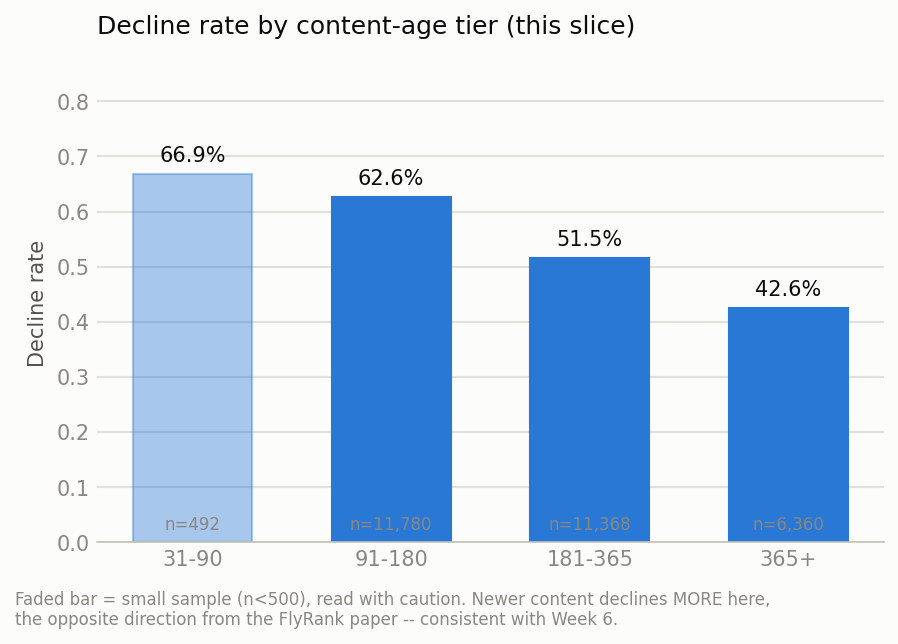

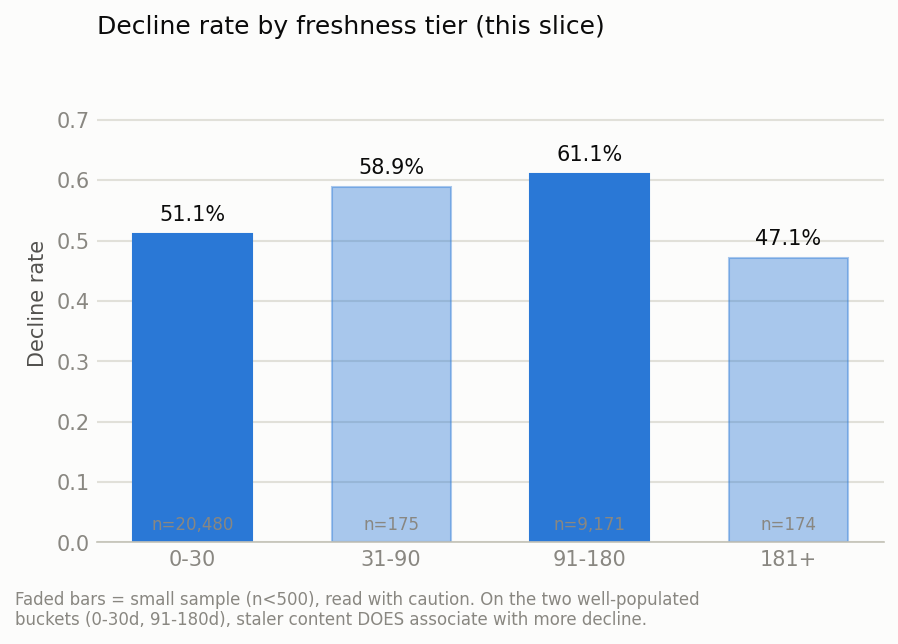

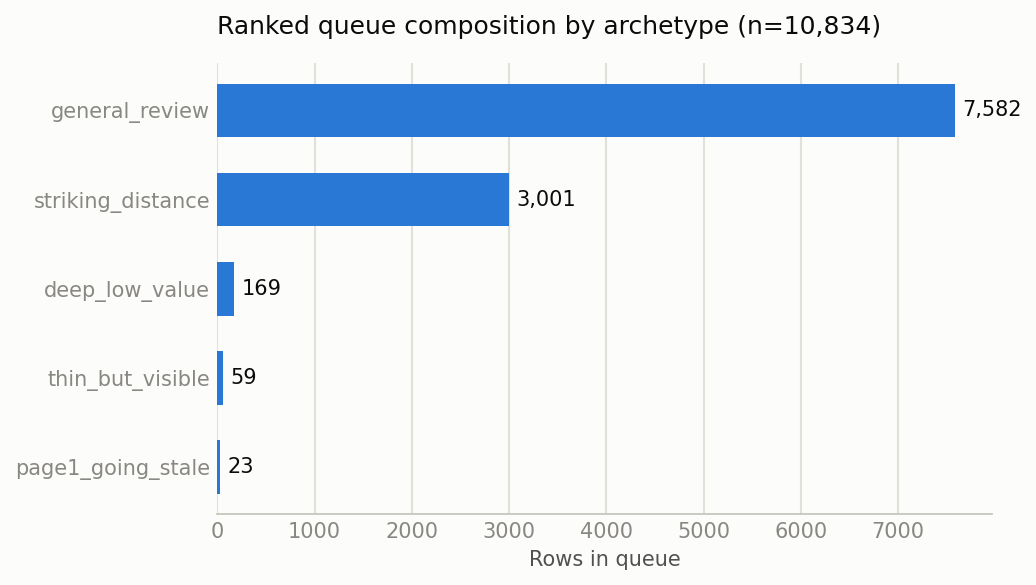

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Export the queue, the metrics receipt, and the figures the paper reuses

def build_action_queue():
    """Rebuilds the Week-6 honest client-grouped model and turns its scores into
    a ranked action queue. Self-contained on purpose -- every section cell in this
    notebook calls this fresh rather than relying on state from an earlier cell."""
    import pandas as pd
    import numpy as np
    from pathlib import Path
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    import warnings
    warnings.filterwarnings('ignore')

    def _find_starter_csv():
        rel = Path("data/raw/content_refresh_anonymized.csv")
        cur = Path.cwd().resolve()
        for _ in range(8):
            cand = cur / rel
            if cand.exists():
                return cand
            if cur.parent == cur:
                break
            cur = cur.parent
        return None

    RAW = _find_starter_csv()
    assert RAW is not None, f"CSV not found from cwd={Path.cwd().resolve()}"
    df = pd.read_csv(RAW)
    df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

    numeric_features = [
        'search_volume', 'competition', 'cpc', 'word_count', 'char_count',
        'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
        'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
        'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update',
        'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct'
    ]
    categorical_features = [
        'competition_level', 'content_type', 'main_intent', 'age_tier',
        'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier'
    ]

    def prepare_features(frame):
        frame = frame.copy()
        for col in ['search_volume', 'competition', 'cpc']:
            frame[f'has_{col}'] = frame[col].notna().astype(int)
        num = frame[numeric_features].fillna(0)
        cat = pd.get_dummies(frame[categorical_features].astype('object'), dummy_na=True)
        flags = frame[[f'has_{c}' for c in ['search_volume', 'competition', 'cpc']]]
        return pd.concat([num, flags, cat], axis=1)

    X_all = prepare_features(df)
    y_all = df['is_declining_label'].values
    groups_all = df['client_id'].values

    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    probs_test = rf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, probs_test)

    def precision_at_k(y_true, y_scores, k):
        if len(y_scores) < k:
            k = len(y_scores)
        idx = np.argsort(-y_scores)[:k]
        return np.mean(y_true[idx])

    k_test = int(len(y_test) * (4732 / len(df)))
    baseline_csv = pd.read_csv('work/outputs/baseline_action_score.csv')
    df_test_baseline = df.iloc[test_idx].merge(baseline_csv[['content_id', 'score']], on='content_id', how='left')
    baseline_probs = df_test_baseline['score'].fillna(0).values
    rf_precision_at_k = precision_at_k(y_test, probs_test, k_test)
    baseline_precision_at_k = precision_at_k(y_test, baseline_probs, k_test)

    scored = df.iloc[test_idx].copy()
    scored['decline_probability'] = probs_test

    # ---- reason codes: five inspectable flags, not a black box ----
    med_engagement = df['engagement_rate'].median()
    med_ctr = df['ctr'].median()

    def reason_flags(row):
        flags = []
        if row['days_since_last_update'] > 90:
            flags.append('stale')
        if row['word_count_tier'] in ('<1000', '1000-2000'):
            flags.append('thin')
        if row['position_tier'] in ('deep', 'page_3_5'):
            flags.append('deep_position')
        if row['engagement_rate'] < med_engagement:
            flags.append('low_engagement')
        if row['ctr'] < med_ctr:
            flags.append('low_ctr')
        return flags

    scored['reason_flags'] = scored.apply(reason_flags, axis=1)
    scored['reason_code'] = scored['reason_flags'].apply(lambda f: '+'.join(f[:2]) if f else 'no_flags')

    # ---- archetype -> action mapping (checked top-down, first match wins) ----
    def archetype_and_action(row):
        if row['position_tier'] in ('top_3', 'page_1') and row['freshness_tier'] == '181+':
            return ('page1_going_stale', 'Priority refresh: protect a page-one asset that is aging out')
        if row['age_tier'] == '365+' and row['freshness_tier'] == '181+':
            return ('old_never_refreshed', 'Priority refresh candidate: oldest, most stale bucket')
        if row['position_tier'] == 'striking':
            return ('striking_distance', 'Targeted relevance/internal-link push toward page 1')
        if row['word_count_tier'] in ('<1000', '1000-2000') and row['impression_tier'] in ('good', 'excellent'):
            return ('thin_but_visible', 'Expand: add missing subtopics, this page already earns impressions')
        if row['position_tier'] == 'deep' and row['impression_tier'] == 'low':
            return ('deep_low_value', 'Do not prioritize for rewrite -- monitor only')
        return ('general_review', 'Standard human review queue, no specific structural pattern flagged')

    arch_action = scored.apply(archetype_and_action, axis=1, result_type='expand')
    scored['archetype'] = arch_action[0]
    scored['recommended_action'] = arch_action[1]

    # ---- cost/value framing: captured click-equivalent value (clicks x CPC), the
    # same choice the FlyRank paper's own Finding #9 argues for over impressions x CPC ----
    scored['value_proxy_usd'] = scored['clicks_90d'] * scored['cpc'].fillna(0)
    scored['value_known'] = scored['cpc'].notna()
    scored['has_captured_value'] = scored['value_known'] & (scored['value_proxy_usd'] > 0)

    med_prob = scored['decline_probability'].median()
    scored['prob_high'] = scored['decline_probability'] >= med_prob

    def quadrant(row):
        if row['prob_high'] and row['has_captured_value']:
            return 'refresh_now'
        if row['prob_high'] and not row['has_captured_value']:
            return 'batch_low_touch'
        if not row['prob_high'] and row['has_captured_value']:
            return 'protect_monitor'
        return 'deprioritize'

    scored['priority_quadrant'] = scored.apply(quadrant, axis=1)

    scored = scored.sort_values('decline_probability', ascending=False).reset_index(drop=True)
    scored.insert(0, 'rank', np.arange(1, len(scored) + 1))

    # Review batches are capped per client. An uncapped top-50-by-probability put 48
    # of 50 rows on just 2 of the 10 test clients -- this spreads review capacity
    # across the whole book instead of burning a week on two portfolios.
    def assign_batches(frame, week_total=50, week_cap_per_client=10, month_total=200, month_cap_per_client=30):
        batch = pd.Series('backlog', index=frame.index)
        client_week_count, client_month_count = {}, {}
        week_n = month_n = 0
        for idx, client in frame['client_id'].items():
            if week_n < week_total and client_week_count.get(client, 0) < week_cap_per_client:
                batch.loc[idx] = 'this_week'
                client_week_count[client] = client_week_count.get(client, 0) + 1
                week_n += 1
            elif month_n < month_total and client_month_count.get(client, 0) < month_cap_per_client:
                batch.loc[idx] = 'this_month'
                client_month_count[client] = client_month_count.get(client, 0) + 1
                month_n += 1
        return batch

    scored['review_batch'] = assign_batches(scored)

    queue_cols = [
        'rank', 'content_id', 'client_id', 'decline_probability', 'archetype',
        'recommended_action', 'reason_code', 'value_proxy_usd', 'value_known',
        'priority_quadrant', 'review_batch', 'position_tier', 'freshness_tier',
        'age_tier', 'word_count_tier',
    ]
    queue = scored[queue_cols].copy()

    metrics = {
        'model': 'RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)',
        'split': 'client-grouped 70/30 (GroupShuffleSplit, random_state=42)',
        'n_train_clients': int(len(set(df.iloc[train_idx]['client_id']))),
        'n_test_clients': int(len(set(df.iloc[test_idx]['client_id']))),
        'n_queue_rows': int(len(queue)),
        'test_auc': float(test_auc),
        'base_rate_test': float(y_test.mean()),
        'k_test': int(k_test),
        'rf_precision_at_k': float(rf_precision_at_k),
        'baseline_precision_at_k': float(baseline_precision_at_k),
        'min_content_age_days_full_dataset': int(df['content_age_days'].min()),
        'has_date_column': bool(any(
            c.lower() in ('date', 'report_date', 'snapshot_date', 'timestamp')
            or c.lower().endswith('_date') or c.lower().endswith('_at')
            for c in df.columns
        )),
        'ambiguous_probability_rows_0.45_0.55': int(((queue['decline_probability'] >= 0.45) & (queue['decline_probability'] <= 0.55)).sum()),
        'value_unknown_rows': int((~queue['value_known']).sum()),
        'archetype_counts': queue['archetype'].value_counts().to_dict(),
        'priority_quadrant_counts': queue['priority_quadrant'].value_counts().to_dict(),
        'review_batch_counts': queue['review_batch'].value_counts().to_dict(),
    }

    fresh_order = ['0-30', '31-90', '91-180', '181+']
    decay_insight = df.groupby('freshness_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(fresh_order)

    age_order = ['31-90', '91-180', '181-365', '365+']
    age_insight = df.groupby('age_tier').agg(
        n=('content_id', 'count'), decline_rate=('is_declining_label', 'mean'),
    ).round(3).reindex(age_order)

    return df, scored, queue, metrics, decay_insight, age_insight

import json
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

df, scored, queue, metrics, decay_insight, age_insight = build_action_queue()

OUTPUTS_DIR = Path('work/outputs')
FIGURES_DIR = Path('work/figures')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---- 1. the queue itself (stays out of git by design -- CI blocks data files) ----
queue_path = OUTPUTS_DIR / 'action_queue.csv'
queue.to_csv(queue_path, index=False)
print(f"Wrote {queue_path} ({len(queue)} rows, {queue_path.stat().st_size:,} bytes) -- gitignored, regenerate by re-running this notebook.")

# ---- 2. the metrics receipt (committed -- the paper's numbers trace back here) ----
metrics_path = OUTPUTS_DIR / 'action_playbook_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Wrote {metrics_path} ({metrics_path.stat().st_size:,} bytes) -- committed.")

# ---- 3. figures (committed) -- palette per skills/../dataviz conventions: single ----
# sequential blue hue for magnitude bars, light chart surface, muted secondary ink ----
SURFACE, INK, INK_SECONDARY, INK_MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE, BLUE = '#e1e0d9', '#c3c2b7', '#2a78d6'

def style_vertical(ax):
    ax.set_facecolor(SURFACE)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, length=0)
    ax.yaxis.grid(True, color=GRID, linewidth=1)
    ax.set_axisbelow(True)

def decline_rate_chart(insight_df, title, note, out_path, small_n_threshold=500):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150, facecolor=SURFACE)
    style_vertical(ax)
    labels = insight_df.index.tolist()
    values = insight_df['decline_rate'].tolist()
    ns = insight_df['n'].tolist()
    alphas = [1.0 if n >= small_n_threshold else 0.4 for n in ns]
    bars = ax.bar(labels, values, width=0.6)
    for bar, v, n, a in zip(bars, values, ns, alphas):
        bar.set_color(BLUE)
        bar.set_alpha(a)
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.1%}",
                ha='center', va='bottom', color=INK, fontsize=10)
        ax.text(bar.get_x() + bar.get_width() / 2, 0.015, f"n={n:,}",
                ha='center', va='bottom', color=INK_MUTED, fontsize=8)
    ax.set_ylim(0, max(values) * 1.3)
    ax.set_title(title, color=INK, fontsize=12, loc='left', pad=14)
    ax.set_ylabel('Decline rate', color=INK_SECONDARY)
    fig.text(0.01, -0.05, note, color=INK_MUTED, fontsize=8, wrap=True)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches='tight', facecolor=SURFACE)
    plt.close(fig)

decline_rate_chart(
    age_insight,
    'Decline rate by content-age tier (this slice)',
    'Faded bar = small sample (n<500), read with caution. Newer content declines MORE here,\n'
    'the opposite direction from the FlyRank paper -- consistent with Week 6.',
    FIGURES_DIR / 'decline_rate_by_age_tier.png',
)
decline_rate_chart(
    decay_insight,
    'Decline rate by freshness tier (this slice)',
    'Faded bars = small sample (n<500), read with caution. On the two well-populated\n'
    'buckets (0-30d, 91-180d), staler content DOES associate with more decline.',
    FIGURES_DIR / 'decline_rate_by_freshness_tier.png',
)

fig, ax = plt.subplots(figsize=(7, 4), dpi=150, facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, length=0)
ax.xaxis.grid(True, color=GRID, linewidth=1)
ax.set_axisbelow(True)
arch_counts = queue['archetype'].value_counts().sort_values(ascending=True)
bars = ax.barh(arch_counts.index, arch_counts.values, height=0.6, color=BLUE)
for bar, v in zip(bars, arch_counts.values):
    ax.text(v + arch_counts.values.max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{v:,}",
            va='center', ha='left', color=INK, fontsize=10)
ax.set_title(f'Ranked queue composition by archetype (n={len(queue):,})', color=INK, fontsize=12, loc='left', pad=14)
ax.set_xlabel('Rows in queue', color=INK_SECONDARY)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'archetype_distribution.png', bbox_inches='tight', facecolor=SURFACE)
plt.close(fig)

for p in sorted(FIGURES_DIR.glob('*.png')):
    print(f"Wrote {p} ({p.stat().st_size:,} bytes) -- committed.")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.